In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df = pd.read_csv("loan_application.csv")

df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,$5849.0
1,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,$6091.0
2,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,$3000.0
3,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,$4941.0
4,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,$6000.0


In [6]:
# Drop Unnecessary Columns
df.drop(['Unnamed: 0','Loan_ID'], axis=1, inplace=True)

In [7]:
#Handle Missing Values
df.fillna(df.mode().iloc[0], inplace=True)

In [8]:
# Convert Total_Income to Numeric
df['Total_Income'] = df['Total_Income'].replace(r'[\$,]', '', regex=True).astype(float)

In [9]:
#Encode Categorical Columns
le = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [10]:
# Split Features and Target
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.87

Confusion Matrix
[[19 12]
 [ 1 68]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.61      0.75        31
           1       0.85      0.99      0.91        69

    accuracy                           0.87       100
   macro avg       0.90      0.80      0.83       100
weighted avg       0.88      0.87      0.86       100



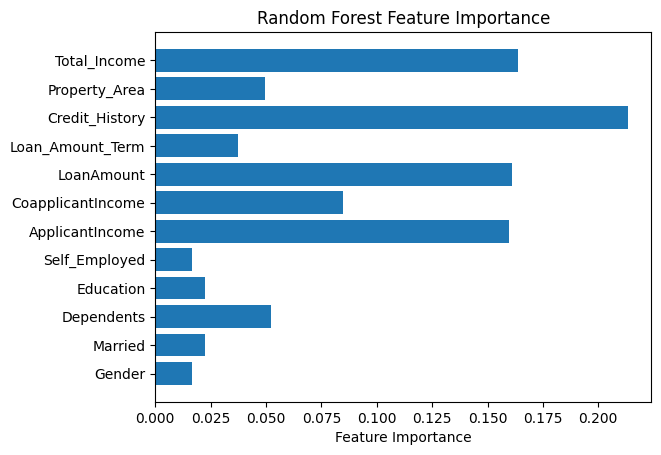

In [14]:
importances = rf.feature_importances_

plt.barh(X.columns, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()